In [3]:
!yes | pip uninstall torchvison
!pip install -qU torchvision

yes: standard output: Broken pipe


In [4]:
%%capture
!pip install -U sagemaker

In [5]:
import os
import json
import random
import numpy as np

import boto3
import sagemaker
from sagemaker.pytorch import PyTorchModel
from sagemaker import get_execution_role, Session
from sagemaker.serializers import JSONSerializer
from sagemaker.deserializers import JSONDeserializer

from utils.mnist import mnist_to_numpy, normalize
import random
import matplotlib.pyplot as plt
%matplotlib inline

## Setup

In [6]:
sess = Session()

role = get_execution_role()

In [7]:
# copy a pretrained model from a public public to your default bucket
s3 = boto3.client("s3")

# upload to default bucket
pt_mnist_model_data = "s3://sagemaker-us-east-1-875716602731/DEMO-mnist/pytorch-training-2024-11-22-21-59-58-707/output/model.tar.gz"

## PyTorchModel Object

In [8]:
model = PyTorchModel(
    entry_point="inference.py",
    source_dir="code",
    role=role,
    model_data=pt_mnist_model_data,
    framework_version="2.4.0",
    py_version="py311",
)

## Deploy Endpoint

In [9]:
local_mode = False

if local_mode:
    instance_type = "local"
else:
    instance_type = "ml.c5.xlarge"

predictor = model.deploy(
    initial_instance_count=1,
    instance_type=instance_type,
    serializer=JSONSerializer(),
    deserializer=JSONDeserializer(),
)


[11/22/24 22:27:16] INFO     Repacking model artifact                                                  ]8;id=289708;file:///opt/conda/lib/python3.11/site-packages/sagemaker/model.py\model.py]8;;\:]8;id=638413;file:///opt/conda/lib/python3.11/site-packages/sagemaker/model.py#819\819]8;;\
                             (s3://sagemaker-us-east-1-875716602731/DEMO-mnist/pytorch-training-2024-1             
                             1-22-21-59-58-707/output/model.tar.gz), script artifact (code), and                   
                             dependencies ([]) into single tar.gz file located at                                  
                             s3://sagemaker-us-east-1-875716602731/pytorch-inference-2024-11-22-22-27-             
                             15-845/model.tar.gz. This may take some time depending on model size...               

                    INFO     Creating model with name: pytorch-inference-2024-11-22-22-27-16-452    ]8;id=746902;file:///opt/conda/lib/python3.11/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=867338;file:///opt/conda/lib/python3.11/site-packages/sagemaker/session.py#4025\4025]8;;\

[11/22/24 22:27:17] INFO     Creating endpoint-config with name                                     ]8;id=89840;file:///opt/conda/lib/python3.11/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=574330;file:///opt/conda/lib/python3.11/site-packages/sagemaker/session.py#5820\5820]8;;\
                             pytorch-inference-2024-11-22-22-27-17-244                                             

                    INFO     Creating endpoint with name pytorch-inference-2024-11-22-22-27-17-244  ]8;id=720396;file:///opt/conda/lib/python3.11/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=556862;file:///opt/conda/lib/python3.11/site-packages/sagemaker/session.py#4642\4642]8;;\

-----!

## Random Test

In [10]:
dummy_data = {"inputs": np.random.rand(16, 1, 28, 28).tolist()}

In [11]:
res = predictor.predict(dummy_data)

In [12]:
print("Predictions:{}, {}".format(len(res), len(res[0])))

Predictions:16, 10


## Actual Test

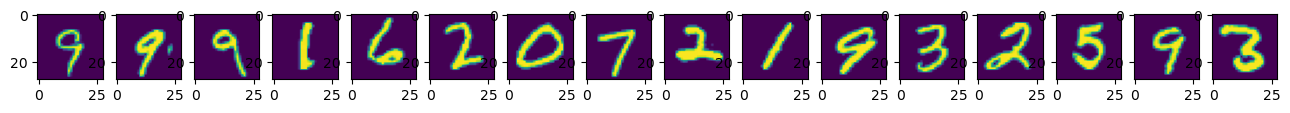

In [13]:
data_dir = "/tmp/data"
X, Y = mnist_to_numpy(data_dir, train=False)

# randomly sample 16 images to inspect
mask = random.sample(range(X.shape[0]), 16)
samples = X[mask]
labels = Y[mask]
# plot the images
fig, axs = plt.subplots(nrows=1, ncols=16, figsize=(16, 1))

for i, splt in enumerate(axs):
    splt.imshow(samples[i])

In [14]:
print(samples.shape, samples.dtype)

(16, 28, 28) uint8


In [15]:
# pre-process the data
samples = normalize(samples.astype(np.float32), axis=(1, 2))

res = predictor.predict({"inputs": np.expand_dims(samples, axis=1).tolist()})

In [16]:
predictions = np.argmax(np.array(res, dtype=np.float32), axis=1).tolist()
print("Predicted digits: ", predictions)

Predicted digits:  [9, 9, 9, 1, 6, 2, 0, 7, 2, 1, 9, 3, 2, 5, 9, 3]


## Cleanup

In [17]:
predictor.delete_endpoint()

[11/22/24 22:31:34] INFO     Deleting endpoint configuration with name:                             ]8;id=149732;file:///opt/conda/lib/python3.11/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=682497;file:///opt/conda/lib/python3.11/site-packages/sagemaker/session.py#4796\4796]8;;\
                             pytorch-inference-2024-11-22-22-27-17-244                                             

[11/22/24 22:31:36] INFO     Deleting endpoint with name: pytorch-inference-2024-11-22-22-27-17-244 ]8;id=345162;file:///opt/conda/lib/python3.11/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=728656;file:///opt/conda/lib/python3.11/site-packages/sagemaker/session.py#4786\4786]8;;\